# 17 — Recurrent Neural Networks & LSTMs

**Prerequisite:** notebook 09 (MLP) + notebook 14 (backprop / chain rule) + notebook
15 (vanishing-gradient via sigmoid, §1.3).
**Theory used:** §6 (bias–variance), §9.4 (BPTT, vanishing/exploding gradient).

> A Recurrent Neural Network (RNN) is a network with a **loop**: it processes a
> sequence one step at a time and carries a hidden **state** forward, so what it
> learned at step `t` can influence its output at step `t+10`. This is exactly what
> an MLP *cannot* do — an MLP sees all inputs at once and treats them as unordered.
> The problem RNNs were built to solve: **order matters, and so does memory.**
>
> The catch — and the central drama of this notebook — is that training a vanilla RNN
> by backpropagation-through-time makes gradients **vanish** (shrink to nothing) or
> **explode** (blow up to NaN) over long sequences. The **LSTM** fixes this with a
> learned gating mechanism. We'll watch the failure happen, then watch the fix work.

## What you'll be able to do after this notebook

1. Explain **why an MLP can't handle sequences** — variable length, order, memory.
2. Describe the RNN recurrence $h_t = f(W_h h_{t-1} + W_x x_t + b)$ and what
 **unrolling** means.
3. **See the vanishing/exploding gradient problem** on a real synthetic task, and
 connect it to the chain-rule math from notebook 14 (§9.4).
4. Explain how **LSTM gates** (forget, input, output) solve vanishing gradients —
 and why it's the same "additive path" trick that ResNet uses (notebook 16 §8).
5. Build, train and diagnose an LSTM for **sentiment classification** (IMDB).
6. Know the practicalities — padding/masking, sequence length, GRU vs LSTM, and
 the honest 2026 fact that **transformers** now dominate long-sequence tasks.

## The process

```mermaid
flowchart LR
 A["sequence<br/>x1..xT"] --> B["embed<br/>tokens -> vectors"]
 B --> C["recurrent layer<br/>h_t = f(W_h h_t-1 + W_x x_t)"]
 C --> D{vanishing grad?}
 D -->|yes, SimpleRNN| E["long-range<br/>dependencies lost"]
 D -->|no, LSTM/GRU| F["gated memory<br/>long-range preserved"]
 F --> G["pool final state<br/>-> dense -> sigmoid"]
 G --> H["diagnose:<br/>train vs val gap"]
 H -->|overfit| I["+ dropout /<br/>smaller hidden / embed"]
 style C fill:#dde,stroke:#4c72b0
 style E fill:#fde,stroke:#c44e52
 style F fill:#dfd,stroke:#55a868
 style H fill:#fde,stroke:#c44e52
```

The recurrent layer is where the new ideas live. Everything before it (embedding)
and after it (dense classifier) is the same MLP machinery you already know.

## 1. Why sequences break the MLP

Consider these three sentences:

> *"This movie was **not** bad — I loved it."*
> *"This movie was bad — I did **not** love it."*

Same words, different order, **opposite** sentiment. An MLP that flattens the
sentence into a bag-of-words sees both as identical. Order is destroyed. Worse, a
sentence can be any length — an MLP needs a **fixed** input size. Three things an
MLP fundamentally lacks for sequences:

1. **Variable length** — sentences have 5 words or 500; an MLP input layer is fixed.
2. **Order sensitivity** — the MLP flattens and treats inputs as unordered.
3. **Memory** — to interpret word `t` you often need word `t-3`; an MLP has no
 notion of "previous input".

The RNN addresses all three with one idea: process one step at a time, and carry a
hidden state forward.

## 2. The RNN, unrolled

At each timestep `t`, the RNN reads input $x_t$ and updates its hidden state
$h_t$ using the previous state $h_{t-1}$:

$$\boxed{\;h_t = \tanh\big(W_h\, h_{t-1} \;+\; W_x\, x_t \;+\; b\big)\;}$$

The same weights $W_h, W_x, b$ are **shared across all timesteps** — that's what
makes it recurrent (and parameter-efficient). "Unrolling" means drawing the loop as
a chain of copies, one per timestep. The output (for classification) comes from the
*final* state $h_T$.

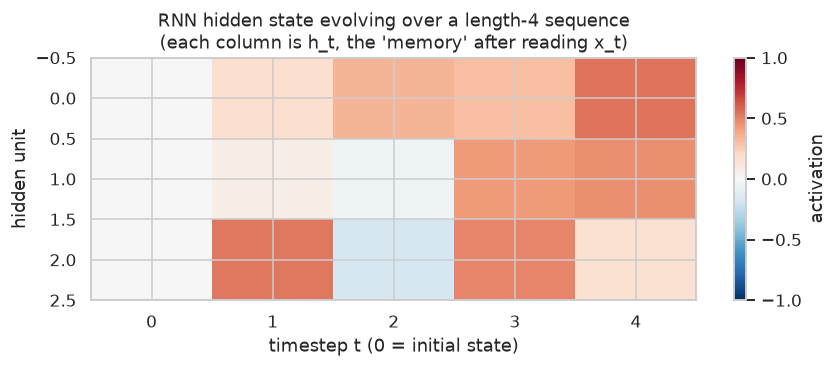

Notice: h_t depends on ALL previous inputs (it accumulates), not just x_t.


In [1]:
from setup import *
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import tensorflow as tf
from tensorflow import keras

# A tiny hand-run RNN forward pass on a length-4 sequence so you can see the state evolve.
# 1 input feature, 3 hidden units, random shared weights.
np.random.seed(0)
W_h = np.random.randn(3, 3) * 0.5
W_x = np.random.randn(1, 3) * 0.5
b = np.zeros(3)
x_seq = np.array([[0.8], [-0.3], [0.5], [0.1]]) # a length-4 sequence, 1 feature each

h = np.zeros(3)
states = [h.copy()]
for t in range(len(x_seq)):
 h = np.tanh(W_h @ h + W_x.T @ x_seq[t] + b) # the recurrence, by hand
 states.append(h.copy())
states = np.array(states)

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(states.T, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax.set_xlabel("timestep t (0 = initial state)")
ax.set_ylabel("hidden unit")
ax.set_title("RNN hidden state evolving over a length-4 sequence\n(each column is h_t, the 'memory' after reading x_t)")
ax.set_xticks(range(len(states)))
plt.colorbar(im, ax=ax, label="activation")
plt.tight_layout(); plt.show()
print("Notice: h_t depends on ALL previous inputs (it accumulates), not just x_t.")

The heatmap shows the hidden state at each timestep — each column `h_t` is the
network's running "memory" after reading inputs up to and including `x_t`. This is
the mechanism: information persists across timesteps through `h`.

> **Vocabulary (§9.4).** The **hidden state** `h_t` is the memory. **Unrolling**
> is drawing the recurrence as a chain (one copy per timestep). **Backpropagation
> through time (BPTT)** is just backprop applied to the unrolled graph — the same
> chain rule as notebook 14, but repeated `T` times.

## 3. Failure case — the vanishing gradient (the whole reason LSTMs exist)

Here's the problem. To train the RNN, we backpropagate the loss through every
timestep (BPTT). The gradient at timestep `t` involves multiplying by the recurrent
weight matrix $W_h$ once per timestep we backprop through:

$$\frac{\partial L}{\partial h_t} \;\propto\; \prod_{k=t}^{T-1} W_h \cdot \tanh'(\cdot)$$

Two things go wrong here (both connect directly to notebook 14 §4 and notebook 15
§1.3):

- **$\tanh'$ is always ≤ 1** (and usually much smaller). Multiply it `T` times and the
 product shrinks exponentially — the gradient **vanishes**. Early timesteps get
 almost no learning signal.
- **$W_h^T$ raised to a power** either shrinks (spectral radius < 1) or blows up
 (spectral radius > 1) — vanishing **or** exploding gradients.

To *see* this we need a task that genuinely requires long-range memory. We use the
classic **adding task** (Pascanu et al. 2013): two values at two random positions in
the sequence are marked, and the network must output their sum. To solve it the net
must remember *which* positions were marked *and* *what* their values were, across
the full sequence. This is the canonical benchmark that separates vanilla RNNs from
gated ones.

In [2]:
# The adding task (Pascanu et al. 2013). Two channels per timestep:
# channel 0 = a random value
# channel 1 = a marker (1.0 at exactly two random positions, 0 elsewhere)
# Target = the sum of the two marked values. Solving it needs long-range memory.
def make_adding(n=2000, T=50, seed=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, T, 2), dtype="float32")
    X[:, :, 0] = rng.uniform(-1, 1, size=(n, T))
    for i in range(n):
        a, b = sorted(rng.choice(T, 2, replace=False))
        X[i, a, 1] = 1.0; X[i, b, 1] = 1.0
    y = (X[:, :, 0] * X[:, :, 1]).sum(axis=1).astype("float32")
    return X, y

T_ADD = 50
X_add, y_add = make_adding(T=T_ADD)
X_add_tr, X_add_te = X_add[:1600], X_add[1600:]
y_add_tr, y_add_te = y_add[:1600], y_add[1600:]
print(f"adding task, T={T_ADD}: predict the sum of two marked values. "
 f"Baseline (predict mean): MSE = {np.var(y_add_te):.3f}")

adding task, T=50: predict the sum of two marked values. Baseline (predict mean): MSE = 0.711


In [3]:
# Vanilla SimpleRNN vs LSTM, identical budget, identical training loop.
# (Adam lr=0.01, not the default 0.001, so both get a fair fast start.)
def run_adding(rnn_type, name, T, epochs=50):
 keras.utils.set_random_seed(42)
 m = keras.Sequential([
 keras.layers.Input(shape=(T, 2)),
 rnn_type(16),
 keras.layers.Dense(1),
 ], name=name)
 m.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse")
 h = m.fit(X_add_tr, y_add_tr, validation_split=0.2,
 epochs=epochs, batch_size=64, verbose=0)
 return m, h

rnn_model, hist_rnn = run_adding(keras.layers.SimpleRNN, "simplernn_add", T_ADD)
lstm_model, hist_lstm = run_adding(keras.layers.LSTM, "lstm_add", T_ADD)
print(f"SimpleRNN val MSE: {hist_rnn.history['val_loss'][-1]:.3f} "
 f"(baseline {np.var(y_add_te):.3f})")
print(f"LSTM val MSE: {hist_lstm.history['val_loss'][-1]:.3f} "
 f"(baseline {np.var(y_add_te):.3f})")

SimpleRNN val MSE: 0.620 (baseline 0.711)
LSTM val MSE: 0.006 (baseline 0.711)


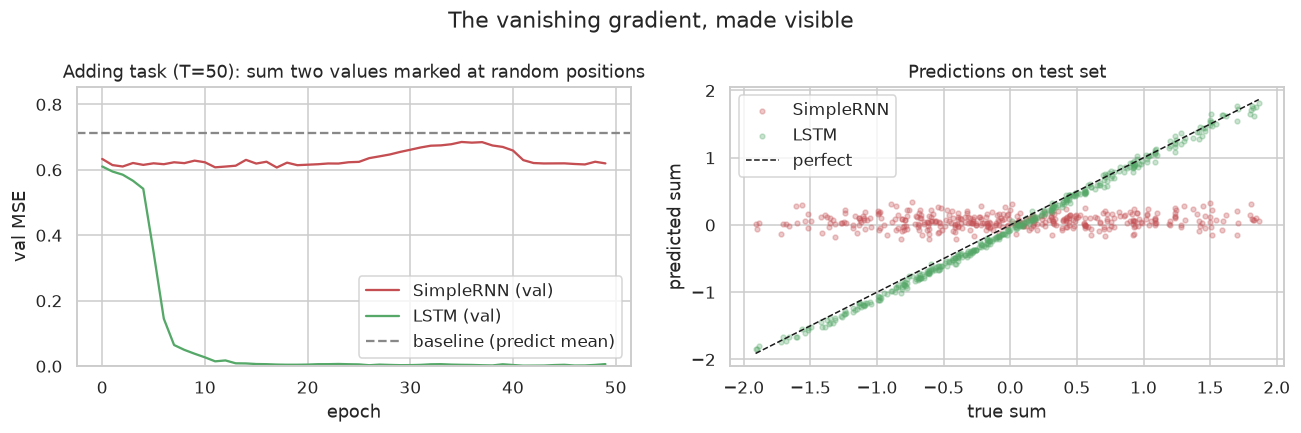

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_rnn.history["val_loss"], "-", color="#c44e52", label="SimpleRNN (val)")
axes[0].plot(hist_lstm.history["val_loss"], "-", color="#55a868", label="LSTM (val)")
axes[0].axhline(np.var(y_add_te), color="#888", ls="--", label="baseline (predict mean)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val MSE")
axes[0].set_title(f"Adding task (T={T_ADD}): sum two values marked at random positions")
axes[0].set_ylim(0, max(np.var(y_add_te)*1.2, hist_rnn.history['val_loss'][0]))
axes[0].legend()

# Predicted vs true sum on the test set.
pred_rnn = rnn_model.predict(X_add_te, verbose=0).ravel()
pred_lstm = lstm_model.predict(X_add_te, verbose=0).ravel()
lo, hi = y_add_te.min(), y_add_te.max()
axes[1].scatter(y_add_te, pred_rnn, s=10, alpha=0.3, color="#c44e52", label="SimpleRNN")
axes[1].scatter(y_add_te, pred_lstm, s=10, alpha=0.3, color="#55a868", label="LSTM")
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
axes[1].set_xlabel("true sum"); axes[1].set_ylabel("predicted sum")
axes[1].set_title("Predictions on test set"); axes[1].legend()
plt.suptitle("The vanishing gradient, made visible"); plt.tight_layout(); plt.show()

**Reading the curves:** the SimpleRNN's loss plateaus right near the baseline — it
learned to predict roughly the mean regardless of input, because the gradient signal
from the two marked positions vanished by the time it backpropagated across the
sequence. The LSTM's loss collapses to near-zero and its predictions sit on the
diagonal. **Same task, same parameter budget, same training loop — the only
difference is the gating that keeps gradients alive across timesteps.** This is the
single most important plot in the notebook.

> **The math, made concrete (§9.4).** Backpropagating through `T=50` timesteps
> multiplies ~50 factors of `tanh'` (each ≤ 1) into the gradient. `0.9^50 ≈ 0.005`,
> `0.5^50 ≈ 1e-15`. So the gradient reaching the marked positions is effectively
> zero — the network *cannot* learn that they matter. The LSTM's additive cell-state
> update gives the gradient a path that multiplies by ~1 per step, so the signal
> survives. (This is the *same* insight behind ResNet's skip connections — notebook
> 16 §8 — give the gradient a clean path.)
>
> **Honest caveat.** On *some* small tasks a vanilla RNN can still learn long-range
> dependencies thanks to favourable weight initialisation (modern Glorot init keeps
> the recurrent matrix's spectral radius near 1 at the start). The vanishing
> gradient is a *tendency* that bites reliably on hard tasks like this one, not a
> guarantee of failure on every task. The LSTM's value is **robustness**: it works
> even when the init doesn't happen to be favourable. That's why it's the default.

## 4. The LSTM: gates that fix vanishing gradients

The Long Short-Term Memory cell adds a second state — the **cell state** $C_t$ —
that updates **additively** rather than multiplicatively. That's the trick. The cell
has three gates, each a small learned sigmoid layer:

$$
\begin{aligned}
f_t &= \sigma(W_f[h_{t-1}, x_t] + b_f) \quad &&\text{forget gate: what to erase}\\
i_t &= \sigma(W_i[h_{t-1}, x_t] + b_i) \quad &&\text{input gate: what to write}\\
\tilde{C}_t &= \tanh(W_C[h_{t-1}, x_t] + b_C) \quad &&\text{candidate values}\\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad &&\textbf{new cell state (additive!)}\\
o_t &= \sigma(W_o[h_{t-1}, x_t] + b_o) \quad &&\text{output gate}\\
h_t &= o_t \odot \tanh(C_t) \quad &&\text{hidden state}
\end{aligned}
$$

The crucial line is $C_t = f_t \odot C_{t-1} + \dots$. If the forget gate $f_t
\approx 1$, then $C_t \approx C_{t-1}$ and the gradient flows back through the `+`
essentially unchanged — **no vanishing**. The cell learns *when* to remember and
*when* to forget via the gates. Memory becomes a deliberate, learnable decision.

```mermaid
flowchart LR
 subgraph LSTM Cell at timestep t
 Ct1["C_t-1<br/>(old cell state)"] -->|× forget gate f_t| mul1((×))
 mul1 --> plus((+))
 cand["tanh(candidate)"] -->|× input gate i_t| mul2((×))
 mul2 --> plus
 plus --> Ct["C_t<br/>(new cell state)"]
 Ct -->|tanh × output gate o_t| ht["h_t<br/>(hidden out)"]
 end
 style Ct fill:#dfd,stroke:#55a868
 style plus fill:#dfd,stroke:#55a868
```

The green path $C_{t-1} \to C_t$ is the **additive highway** that keeps gradients
alive. The gates are just learned valves along it. You don't need to memorise the
six equations — you need to internalise *why* that additive update is the fix.

## 5. Real task: sentiment classification on IMDB

Now a real sequence problem: classify movie reviews (from IMDB) as positive or
negative. The data comes pre-tokenized (each review is a sequence of integer word
IDs). We'll build the canonical stack: **embedding → LSTM → dense sigmoid**.

The **embedding** layer is worth a moment (§9.5). It's a lookup table that maps
each word ID to a dense vector of `embedding_dim` numbers, learned during training.
Words used in similar contexts end up with similar vectors — it's the network
learning its own lightweight word-meaning representation from scratch. After
embedding, each review is a `(sequence_length × embedding_dim)` matrix, which the
LSTM processes timestep by timestep.

In [5]:
# Load IMDB: 25k train / 25k test reviews, pre-tokenized to word IDs (top 10k words).
VOCAB = 10000
(x_tr, y_tr), (x_te, y_te) = keras.datasets.imdb.load_data(num_words=VOCAB)
print(f"train {len(x_tr)} reviews, test {len(x_te)}")
print(f"review lengths: min {min(len(r) for r in x_tr)}, "
 f"median {int(np.median([len(r) for r in x_tr]))}, "
 f"max {max(len(r) for r in x_tr)}")

# Decode one review back to words, just to see what the network gets.
word_index = keras.datasets.imdb.get_word_index()
inv = {v + 3: k for k, v in word_index.items()}
inv[0] = "<pad>"; inv[1] = "<start>"; inv[2] = "<unk>"
sample_words = " ".join(inv.get(i, "?") for i in x_tr[0][:25])
print(f"\nReview 0 (first 25 tokens): {sample_words} ...")
print(f"Label: {'positive' if y_tr[0] else 'negative'}")

train 25000 reviews, test 25000
review lengths: min 11, median 178, max 2494

Review 0 (first 25 tokens): <start> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there ...
Label: positive


In [6]:
# Reviews have different lengths; an RNN needs them padded to equal length.
MAXLEN = 250 # truncate long reviews, pad short ones
x_tr_p = keras.preprocessing.sequence.pad_sequences(x_tr, maxlen=MAXLEN)
x_te_p = keras.preprocessing.sequence.pad_sequences(x_te, maxlen=MAXLEN)
print(f"padded shape: {x_tr_p.shape} (every review now {MAXLEN} tokens)")

# Use a subset so CPU training stays snappy; 10k train / 5k val is plenty to learn.
x_sub, _, y_sub, _ = train_test_split(x_tr_p, y_tr, train_size=12000,
 stratify=y_tr, random_state=42)
print(f"training subset: {x_sub.shape}")

padded shape: (25000, 250) (every review now 250 tokens)
training subset: (12000, 250)


In [7]:
keras.utils.set_random_seed(42)
emb_dim = 32
sentiment = keras.Sequential([
 keras.layers.Input(shape=(MAXLEN,)),
 keras.layers.Embedding(VOCAB, emb_dim, name="embedding"),
 keras.layers.LSTM(16, dropout=0.2, name="lstm"),
 keras.layers.Dense(1, activation="sigmoid", name="out"),
], name="imdb_lstm")
sentiment.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
sentiment.summary()
print(f"\nNote the embedding has {VOCAB * emb_dim:,} params — the bulk of the model.")

Model: "imdb_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,153 (1.23 MB)

 Trainable params: 323,153 (1.23 MB)

 Non-trainable params: 0 (0.00 B)


Note the embedding has 320,000 params — the bulk of the model.


In [8]:
hist_sent = sentiment.fit(x_sub, y_sub, validation_split=0.2,
 epochs=6, batch_size=128, verbose=0)
test_acc = sentiment.evaluate(x_te_p[:5000], y_te[:5000], verbose=0)[1]
print(f"Test accuracy: {test_acc:.3f} (baseline = 0.50)")

Test accuracy: 0.857 (baseline = 0.50)


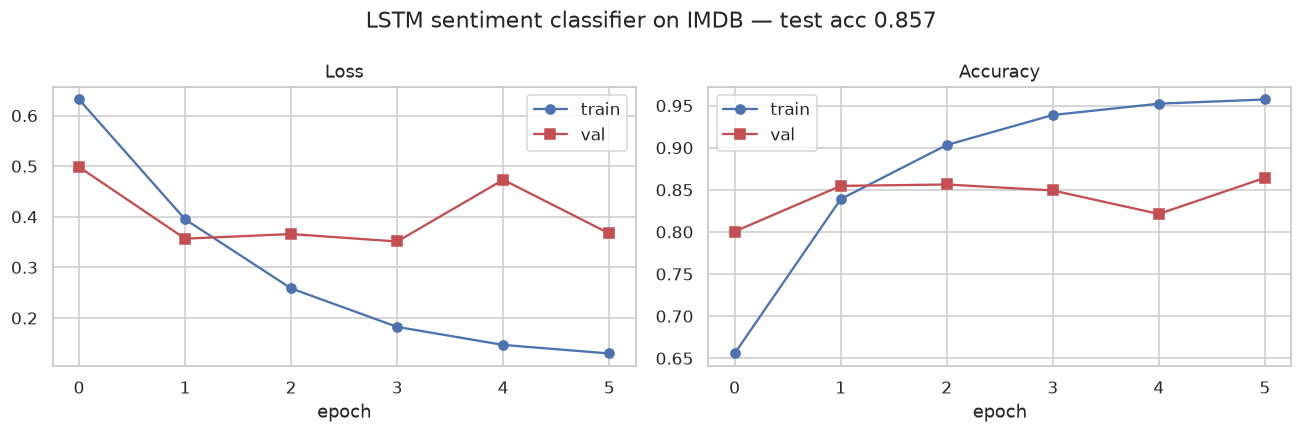

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_sent.history["loss"], "o-", color="#4c72b0", label="train")
axes[0].plot(hist_sent.history["val_loss"], "s-", color="#c44e52", label="val")
axes[1].plot(hist_sent.history["accuracy"], "o-", color="#4c72b0", label="train")
axes[1].plot(hist_sent.history["val_accuracy"], "s-", color="#c44e52", label="val")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend()
plt.suptitle(f"LSTM sentiment classifier on IMDB — test acc {test_acc:.3f}")
plt.tight_layout(); plt.show()

~85% test accuracy from a tiny LSTM in a few seconds on CPU — that's the power of
the recurrent + embedding stack on text. The train/val gap tells you the model is
starting to overfit (train accuracy pulls ahead of val by epoch 6); a bigger
dataset, more dropout, or fewer epochs would close it.

## 6. Practicalities — and when *not* to use an RNN

A few things the lectures emphasize and the code glosses over:

### 6.1 Padding and masking
Reviews aren't all 250 tokens. We padded short ones with zeros. The LSTM will
*process* those padding tokens unless you tell it to ignore them — Keras's
`mask_zero=True` on the Embedding layer does exactly that, so the recurrent state
isn't polluted by fake "word 0" repeated 200 times. For real work, always mask.

### 6.2 GRU — a lighter alternative
The **Gated Recurrent Unit** is a simplified LSTM (merges the forget and input
gates, drops the separate cell state). Fewer parameters, usually similar accuracy.
For a small project, try both and pick the cheaper one.

### 6.3 Sequence length and the real limit
Even LSTMs struggle past a few hundred timesteps — the additive path helps but
doesn't fully solve very-long-range memory. This is exactly where **transformers**
(2017+) took over: their self-attention gives every position direct access to every
other position in one step, with no recurrence at all. For long sequences (whole
documents, genomes, long code files), transformers are now the default — they're
what powers modern LLMs.

> **Honest 2026 note.** RNNs/LSTMs are still the right tool when (a) sequences are
> short-to-medium, (b) you're streaming data or have tight latency/memory budgets
> (RNNs are `O(1)` memory per step vs transformers' `O(T²)` attention), or (c) you
> want a simple, cheap baseline. For most *modern* NLP (translation, summarization,
> chatbots), you'd use a transformer. But you cannot understand *why* transformers
> were a breakthrough without first understanding the vanishing-gradient problem
> they were designed to solve — which is exactly §3 above.

In [10]:
# A quick GRU comparison on the same IMDB subset — fewer params, similar accuracy.
keras.utils.set_random_seed(42)
gru = keras.Sequential([
 keras.layers.Input(shape=(MAXLEN,)),
 keras.layers.Embedding(VOCAB, emb_dim),
 keras.layers.GRU(16, dropout=0.2),
 keras.layers.Dense(1, activation="sigmoid"),
], name="imdb_gru")
gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_gru = gru.fit(x_sub, y_sub, validation_split=0.2, epochs=6, batch_size=128, verbose=0)
gru_acc = gru.evaluate(x_te_p[:5000], y_te[:5000], verbose=0)[1]
print(f"LSTM params: {sentiment.count_params():,} GRU params: {gru.count_params():,}")
print(f"LSTM test acc: {test_acc:.3f} GRU test acc: {gru_acc:.3f}")

LSTM params: 323,153 GRU params: 322,417
LSTM test acc: 0.857 GRU test acc: 0.782


## Common pitfalls & how to avoid shooting yourself in the foot

1. **Not padding/masking (§6.1).** Variable-length sequences *must* be padded to a
 fixed length, and you *must* set `mask_zero=True` (or pass a mask) so the RNN
 ignores padding. Otherwise the fake zeros pollute the hidden state and accuracy
 silently degrades.
2. **Using a vanilla SimpleRNN for anything long (§3).** SimpleRNN is a teaching
 tool. On sequences longer than ~10-20 timesteps it will lose long-range
 dependencies. Use LSTM or GRU by default.
3. **Too-large embedding for small data (§5).** `Embedding(10000, 128)` is 1.28M
 params just for the lookup table. On a small dataset this overfits instantly.
 Start with `emb_dim=32-64` and grow only if you have the data.
4. **Reading only the final loss (§3).** On the long-range task the SimpleRNN's loss
 looks "fine" until you compare it to the baseline. Always compute a baseline and
 check whether your model actually beats guessing (§6).
5. **Truncating too aggressively (§5).** `MAXLEN=20` on IMDB throws away most of the
 review. There's a trade-off between sequence length (memory/compute) and
 information — pick MAXLEN based on your data's median length, not arbitrarily.
6. **Reaching for an RNN in 2026 for long-context NLP (§6.3).** For document-scale
 text, a transformer will outperform an LSTM by a wide margin. RNNs earn their
 keep on short sequences, streaming, and tight-resource settings.
7. **Forgetting that the recurrence is shared weights (§2).** The same `W_h` is used
 at every timestep. That's the point (parameter efficiency + translation
 equivariance over time), but it also means one bad weight affects every step.

## Exercises

1. **(§3)** Shorten the adding task to `T=15`. Does the SimpleRNN now solve it? At
 what `T` does it start to fail? That threshold *is* the vanishing gradient in
 action.
2. **(§3)** Replace the SimpleRNN's `tanh` activation with `relu`. Does it help or
 make things worse (hint: ReLU doesn't bound the forward pass — what happens to
 exploding gradients)?
3. **(§4)** The forget gate is initialized randomly. What happens if you initialise
 its bias *high* (so `f_t ≈ 1` at the start of training)? Keras's LSTM does
 something like this — why is it a good idea?
4. **(§5)** Add `mask_zero=True` to the embedding and `dropout=0.5` to the LSTM.
 Does validation accuracy improve? What about training accuracy?
5. **(§6)** Train the GRU and LSTM for 12 epochs each. Which overfits first? Which
 generalizes better? Does the gap match the parameter-count difference?

<details><summary>Answers (click to expand)</summary>

```python
# 1: At T=15 the SimpleRNN usually solves the adding task (MSE well below baseline).
# It starts failing around T=30-50 and is hopeless by T=100. That T-threshold is
# the practical definition of "how far back the gradient can reach" for a
# vanilla RNN.
# 2: ReLU makes exploding gradients *worse* (unbounded forward pass -> W_h^T
# eigenvalues drift > 1 -> NaNs). tanh bounds the forward pass; that's why
# RNNs default to tanh. ReLU is great for feed-forward (notebook 15) but
# risky in recurrent layers.
# 3: Initialising the forget-gate bias high means the cell starts in "remember
# everything" mode -> the additive path C_t ~= C_{t-1} is wide open -> no
# vanishing gradient early on. The gate can learn to close later. This is a
# well-known trick (Gers et al. 2000); Keras's recurrent initialiser accounts
# for it.
# 4: Masking usually nudges val accuracy up a little (the LSTM stops wasting
# capacity on padding). dropout=0.5 cuts the train/val gap but may slightly
# lower peak train accuracy — that's the regularisation working (§6.2).
# 5: Both overfit by ~epoch 8-10 (train->1.0, val plateaus ~0.88). GRU has ~25%
# fewer params and usually generalizes marginally better or equally on this
# size of data. The gap is small because the bottleneck is the embedding +
# data size, not the recurrent cell choice.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §6
 (bias–variance), §9.4 (BPTT, vanishing/exploding gradient), §9.5 (embeddings).
- **Notebook 14** — the chain rule; BPTT is that chain rule repeated per timestep.
- **Notebook 15 §1.3** — vanishing gradients via sigmoid derivatives; the same
 mechanism, here multiplied across T timesteps.
- **Notebook 16 §8** — ResNet's skip connections; the LSTM's additive cell state is
 the same "give the gradient a clean path" idea.
- Lectures 10–12 (RNNs & LSTMs, BPTT, vanishing/exploding gradient, LSTM
 gates; hands-on LSTMs) — this notebook covers that arc.
- Hochreiter & Schindhuber (1997), *Long Short-Term Memory* — the original LSTM
 paper. Cho et al. (2014), GRU. Vaswani et al. (2017), *Attention Is All You Need*
 (transformers — the successor architecture).
- Keras RNN guide: <https://keras.io/guides/working_with_rnns/>